In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Bootstrapping function for median MAE and CI
def bootstrap_ci_mae(preds, test):
    boot_meds = []
    for i in range(preds.shape[0]):
        boot_meds.append(np.mean(np.abs(preds[i, :]*40.76 - test*40.76)))
    return np.median(boot_meds), np.percentile(boot_meds, 2.5), np.percentile(boot_meds, 97.5)


def plot_mae_by_true_time(models, model_names, suffixes, result_dir, preds_dir, n_bins=3):
    sns.set(style="whitegrid", context="paper")
    plt.rcParams.update({
        "font.family": "serif",
        "axes.titlesize": 20,
        "axes.labelsize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
        "figure.dpi": 300
    })


    for suffix in suffixes:
        orig_y_test = joblib.load(os.path.join(result_dir, f'orig_y_test_{suffix}.joblib'))
        y_test = joblib.load(os.path.join(result_dir, f'y_test_{suffix}.joblib'))
        binary_y_test = joblib.load(os.path.join(result_dir, f'binary_y_test_{suffix}.joblib'))

        # Fixed binning based on full data (or use uncensored only if you prefer)
        bin_edges = pd.qcut(orig_y_test, q=10, retbins=True, labels=False, duplicates='drop')[1]
        bin_labels = [f"{bin_edges[i]:.1f}-{bin_edges[i+1]:.1f}" for i in range(len(bin_edges)-1)]
        x = np.arange(len(bin_labels))

        masks = {
            'Censored': binary_y_test == 0,
            'Uncensored': binary_y_test == 1
        }

        all_df_plot = []

        for label, mask in masks.items():
            if not np.any(mask):
                print(f"[{suffix}] No {label.lower()} samples — skipping.")
                continue

            mask_orig_y = orig_y_test[mask]
            y_bins = pd.cut(mask_orig_y, bins=bin_edges, labels=False, include_lowest=True)

            for model, modelname in zip(models, model_names):
                preds = []
                for splitidx in range(1000):
                    pred_path = os.path.join(preds_dir, f'{model}_y_test_pred_split{splitidx}_{suffix}.joblib')
                    preds.append(joblib.load(pred_path))
                preds = np.array(preds)

                for b in np.unique(y_bins):
                    bin_mask = (y_bins == b)
                    if not np.any(bin_mask):
                        continue
                    idx = np.where(mask)[0][bin_mask]
                    mae, lo, hi = bootstrap_ci_mae(preds[:, idx], orig_y_test[idx])
                    all_df_plot.append({
                        "Model": modelname,
                        "Censoring": label,
                        "TTE Bin": bin_labels[b],
                        "TTE Bin Index": b,
                        "MAE": mae,
                        "MAE_Lower": lo,
                        "MAE_Upper": hi
                    })

        df_plot = pd.DataFrame(all_df_plot)
        df_plot = df_plot.sort_values(by="TTE Bin Index")

        # Plotting
        fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
        bar_width = 0.2
        n_models = len(model_names)
        offsets = np.linspace(-bar_width * (n_models - 1) / 2,
                              bar_width * (n_models - 1) / 2,
                              n_models)

        palette = sns.color_palette("colorblind", n_colors=n_models)
        hatches = {'Censored': '//', 'Uncensored': ''}

        for ax, censoring in zip(axes, ['Censored', 'Uncensored']):
            ax.set_title(f"{censoring} Samples")

            for i, modelname in enumerate(model_names):
                subset = df_plot[(df_plot["Model"] == modelname) & (df_plot["Censoring"] == censoring)]
                if subset.empty:
                    continue

                bin_indices = subset["TTE Bin Index"].values
                bar_x = np.array(bin_indices) + offsets[i]

                mae = subset["MAE"].values
                err = [
                    mae - subset["MAE_Lower"].values,
                    subset["MAE_Upper"].values - mae
                ]
                bars = ax.bar(bar_x, mae, width=bar_width, label=modelname,
                              color=palette[i])
                ax.errorbar(bar_x, mae, yerr=err, fmt='none', ecolor='black', capsize=3, linewidth=1)

            ax.set_xticks(x)
            ax.set_xticklabels(bin_labels, rotation=30, ha='right')
            ax.set_xlabel("True TTE (Binned)")
            ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

        axes[0].set_ylabel("MAE")

        # One legend on the right
        handles, labels = axes[1].get_legend_handles_labels()
        axes[1].legend(handles, labels, title="Model", loc='center left', bbox_to_anchor=(1.0, 0.5))

        fig.suptitle(f"MAE vs. True Time-to-Event — Cohort: {suffix}", fontsize=16)
        fig.tight_layout()
        fig.subplots_adjust(right=0.85, top=0.88)
        plt.savefig(f'mae_bytime{suffix}.png')


    
params = []
hospital_types = ['low_resource', 'high_resource']
strategies = ['covariate']
thresholds = [20, 40, 60, 80]
for strategy in strategies:
    if strategy == 'hybrid':
        params.extend(['%s_T%d_%s'%(strategy, t, h) for t in thresholds for h in hospital_types])
    elif strategy == 'outcome':
        params.extend(['%s_T%d'%(strategy, t) for t in thresholds])
    elif strategy == 'covariate':
        params.extend(['%s_%s'%(strategy, h) for h in hospital_types])

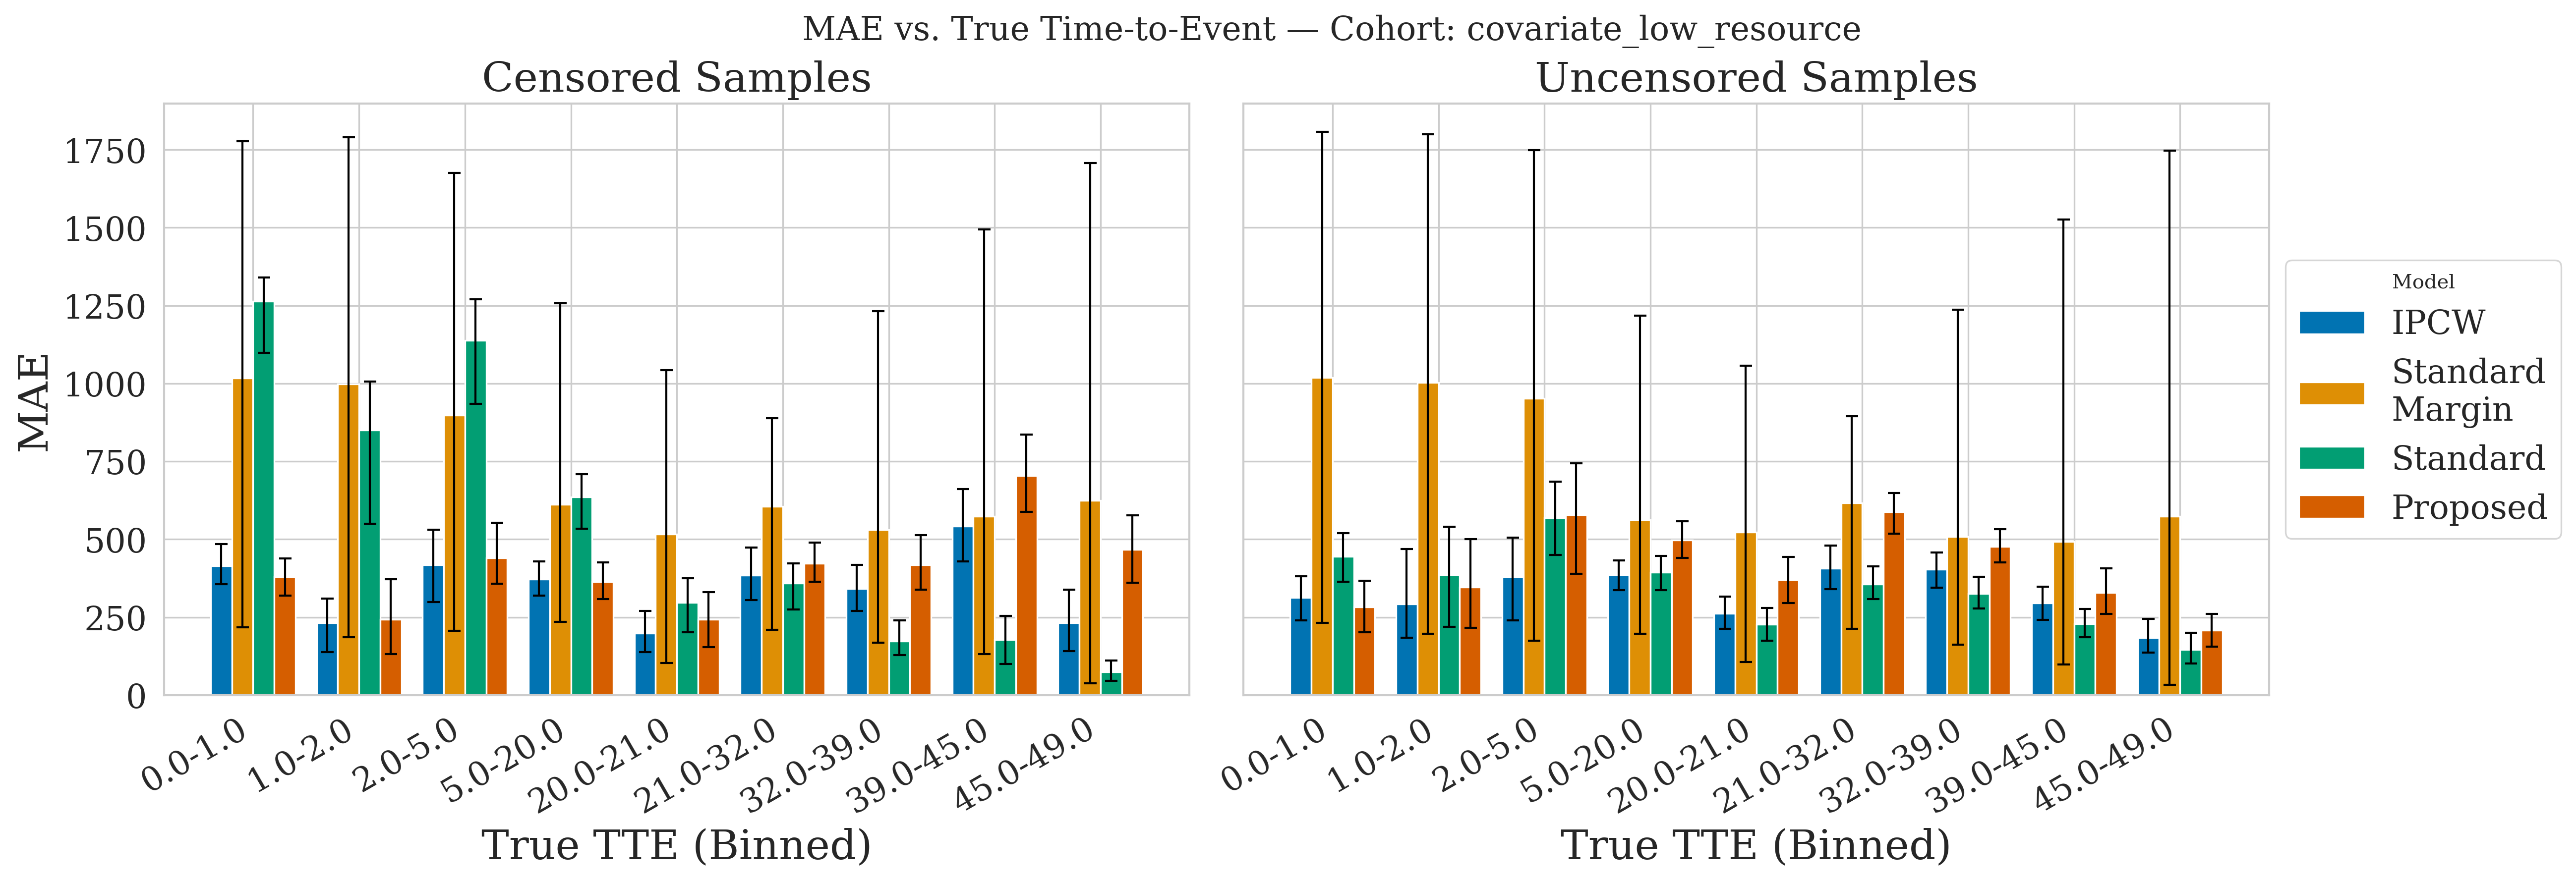

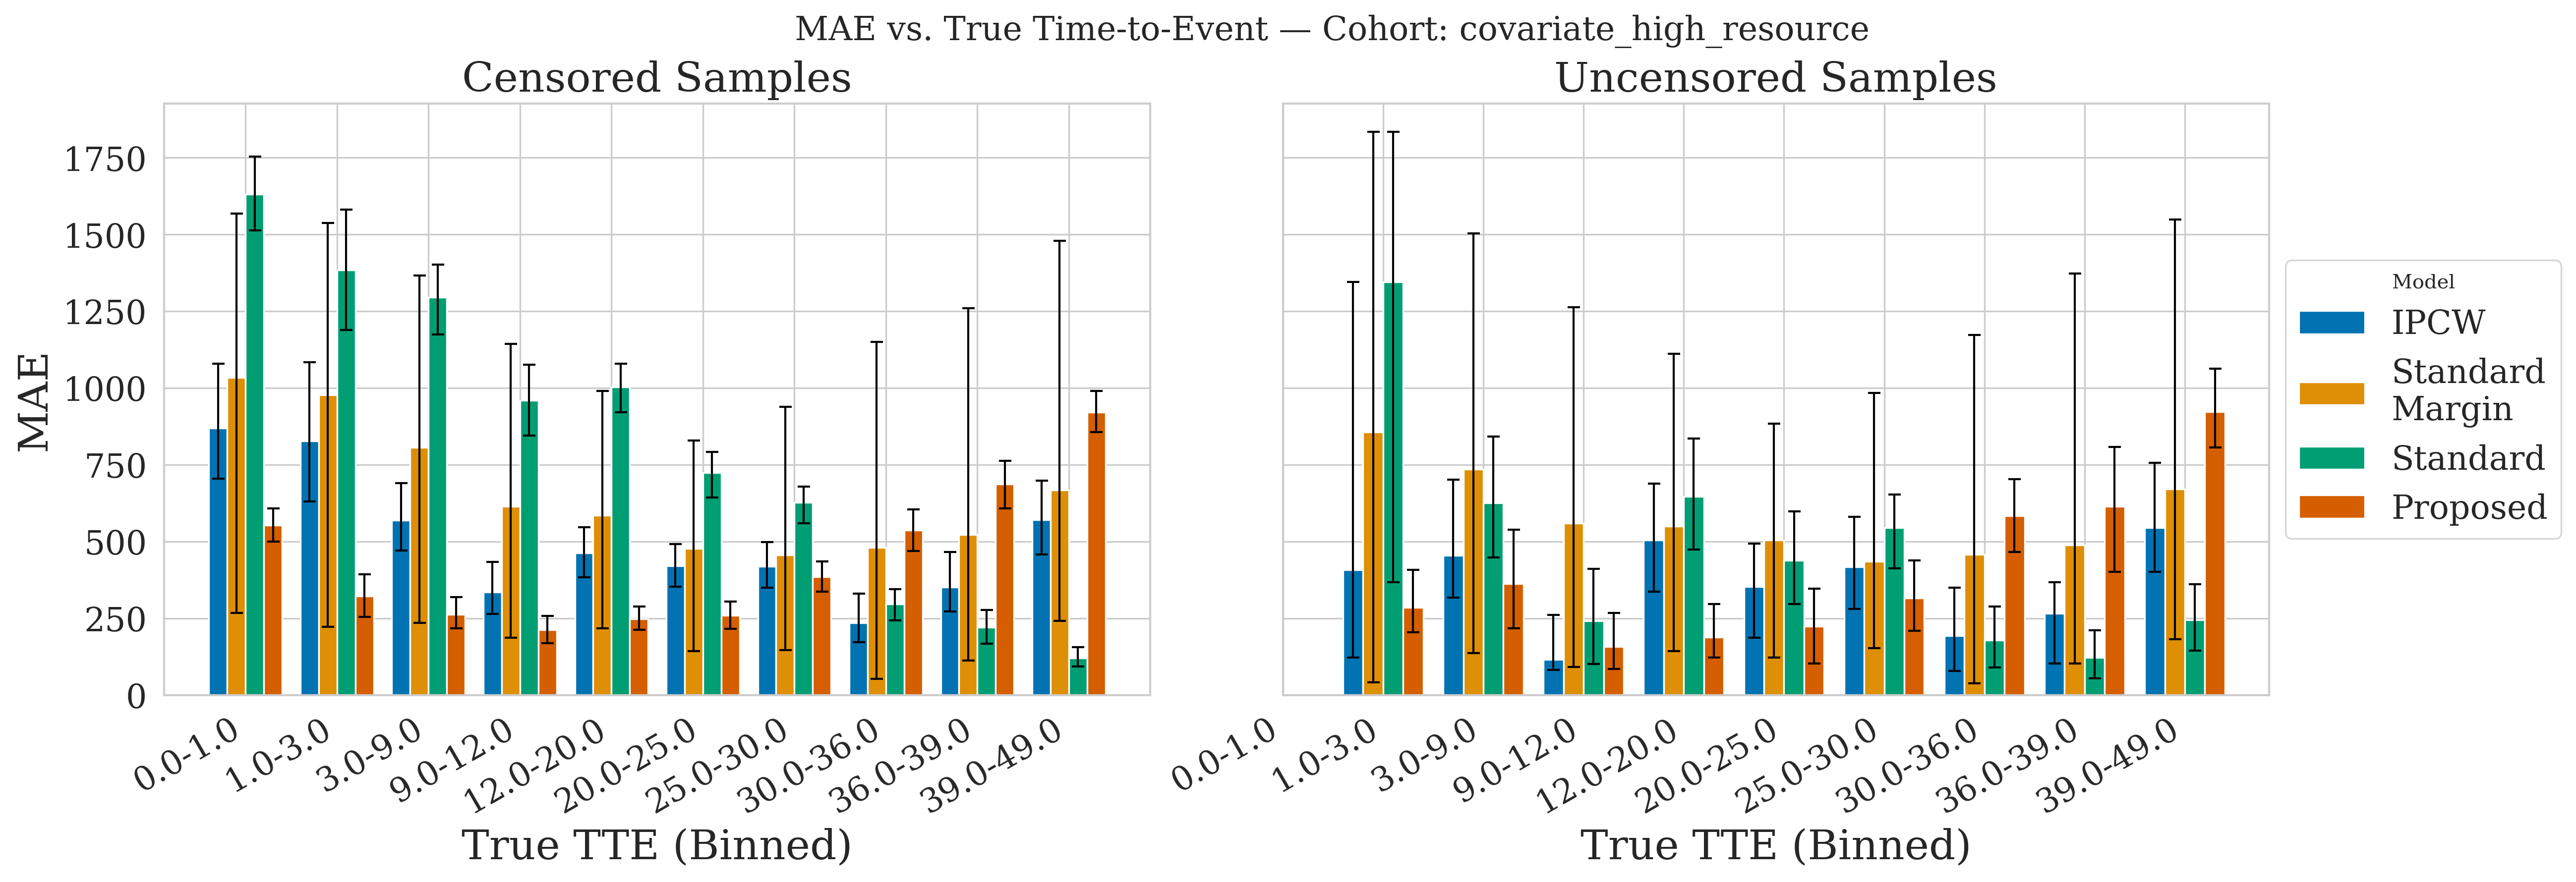

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import joblib



plot_mae_by_true_time(
    models=['icind', 'pcind', 'dhcind', 'proposed'],
    model_names=['IPCW', "Standard\nMargin", 'Standard', 'Proposed'],
    suffixes=params,
    result_dir='$CWITE_DATA_ROOT/support50_propbin_data',
    preds_dir='$CWITE_DATA_ROOT/support50_propbin_test_preds'
)


In [3]:
def plot_mae_split_panels(models, model_names, suffixes, suffixes_proper, result_dir, preds_dir, save_dir=None, method_order=None):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import os
    import joblib
    import pandas as pd

    sns.set(style="whitegrid", context="paper")
    plt.rcParams.update({
        "font.family": "serif",
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 14,
        "figure.dpi": 300
    })

    if method_order is None:
        method_order = model_names

    color_palette = sns.color_palette("colorblind", n_colors=len(method_order))
    method_colors = {method: color_palette[i] for i, method in enumerate(method_order)}

    fig, axs = plt.subplots(1, 2, figsize=(18, 4), sharey=True)

    for ax, suffix, suffixproper in zip(axs, suffixes, suffixes_proper):
        orig_y_test = joblib.load(os.path.join(result_dir, f'orig_y_test_{suffix}.joblib'))
        binary_y_test = joblib.load(os.path.join(result_dir, f'binary_y_test_{suffix}.joblib'))

        masks = {
            'Censored': binary_y_test == 0,
            'Uncensored': binary_y_test == 1
        }

        all_data = []
        oracle_vals = {}

        for group_short, mask in masks.items():
            if not np.any(mask):
                continue

            for model, modelname in zip(models, model_names):
                preds = []
                for splitidx in range(1000):
                    pred_path = os.path.join(preds_dir, f'{model}_y_test_pred_split{splitidx}_{suffix}.joblib')
                    preds.append(joblib.load(pred_path))
                preds = np.array(preds)

                idx = np.where(mask)[0]
                mae_vals = np.mean(np.abs(preds[:, idx] - orig_y_test[idx])* 40.76, axis=1)
                mae = np.median(mae_vals)
                lo = np.percentile(mae_vals, 2.5)
                hi = np.percentile(mae_vals, 97.5)

                if modelname.lower() == "oracle":
                    oracle_vals[group_short] = (mae, lo, hi)
                    continue

                all_data.append({
                    "Method": modelname,
                    "Group": group_short,
                    "MAE": mae,
                    "MAE_Lower": lo,
                    "MAE_Upper": hi,
                    "Count": np.sum(mask)
                })

        df_plot = pd.DataFrame(all_data)
        groups = ["Censored", "Uncensored"]
        width = 0.2
        x_locs = np.arange(len(groups))  # 0 for Censored, 1 for Uncensored

        # Symmetric offsets centered at 0
        total_bar_span = width * len(method_order)
        offsets = np.linspace(-total_bar_span / 2 + width / 2,
                              total_bar_span / 2 - width / 2,
                              len(method_order))

        # Track actual bar positions for each group
        bar_positions_by_group = {g: [] for g in groups}

        # Draw bars
        for i, method in enumerate(method_order):
            for j, group in enumerate(groups):
                x_center = x_locs[j]
                x = x_center + offsets[i]
                row = df_plot[(df_plot["Method"] == method) & (df_plot["Group"] == group)]
                if row.empty:
                    continue

                bar_positions_by_group[group].append(x)

                row = row.iloc[0]
                ax.bar(x, row["MAE"], color=method_colors[method], width=width, label=method if j == 0 else None, zorder=3)
                ax.errorbar(
                    x, row["MAE"],
                    yerr=[[row["MAE"] - row["MAE_Lower"]], [row["MAE_Upper"] - row["MAE"]]],
                    fmt='none', ecolor='black', capsize=3, linewidth=1, zorder=4
                )

        # Draw gray box behind Censored group
        censored_xs = bar_positions_by_group["Censored"]
        if censored_xs:
            censored_start = min(censored_xs) - width / 2 - 0.05
            censored_end = max(censored_xs) + width / 2 + 0.05
            ax.axvspan(censored_start, censored_end, color="lightgrey", alpha=0.3, zorder=0)

        # Draw Oracle lines
        for group in groups:
            if group in oracle_vals and bar_positions_by_group[group]:
                med, lo, hi = oracle_vals[group]
                xs = bar_positions_by_group[group]
                group_start = min(xs) - width / 2
                group_end = max(xs) + width / 2

                ax.fill_between(
                    [group_start, group_end],
                    lo, hi,
                    color='black',
                    alpha=0.2,
                    zorder=4
                )
                ax.hlines(
                    y=med,
                    xmin=group_start,
                    xmax=group_end,
                    color='black',
                    linestyle='--',
                    linewidth=3,
                    zorder=5
                )

        # Set empty ticks and manually add group labels above
        ax.set_xticks(x_locs)
        ax.set_xticklabels(["", ""])

        for group in groups:
            if not bar_positions_by_group[group]:
                continue
            label_x = np.mean(bar_positions_by_group[group])
            n_val = int(df_plot[df_plot["Group"] == group]["Count"].values[0])
            y_text = df_plot["MAE_Upper"].max() * 1.1
            ax.text(label_x, y_text, f"{group} (N={n_val})", ha="center", fontsize=14, fontweight="bold")



        ax.set_title(f"Cohort: {suffixproper}")
        ax.set_ylabel("Mean Absolute Error\n(MAE) in Days" if ax == axs[0] else None)
        ax.set_ylim(0, df_plot["MAE_Upper"].max() * 1.2)

    axs[-1].legend(title="Method", loc='upper left', bbox_to_anchor=(1, 0.7))
    plt.tight_layout()

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, "mae_all.png"), bbox_inches="tight")

    plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '$CWITE_DATA_ROOT/support50_propbin_test_preds/oracle_y_test_pred_split0_covariate_low_resource.joblib'

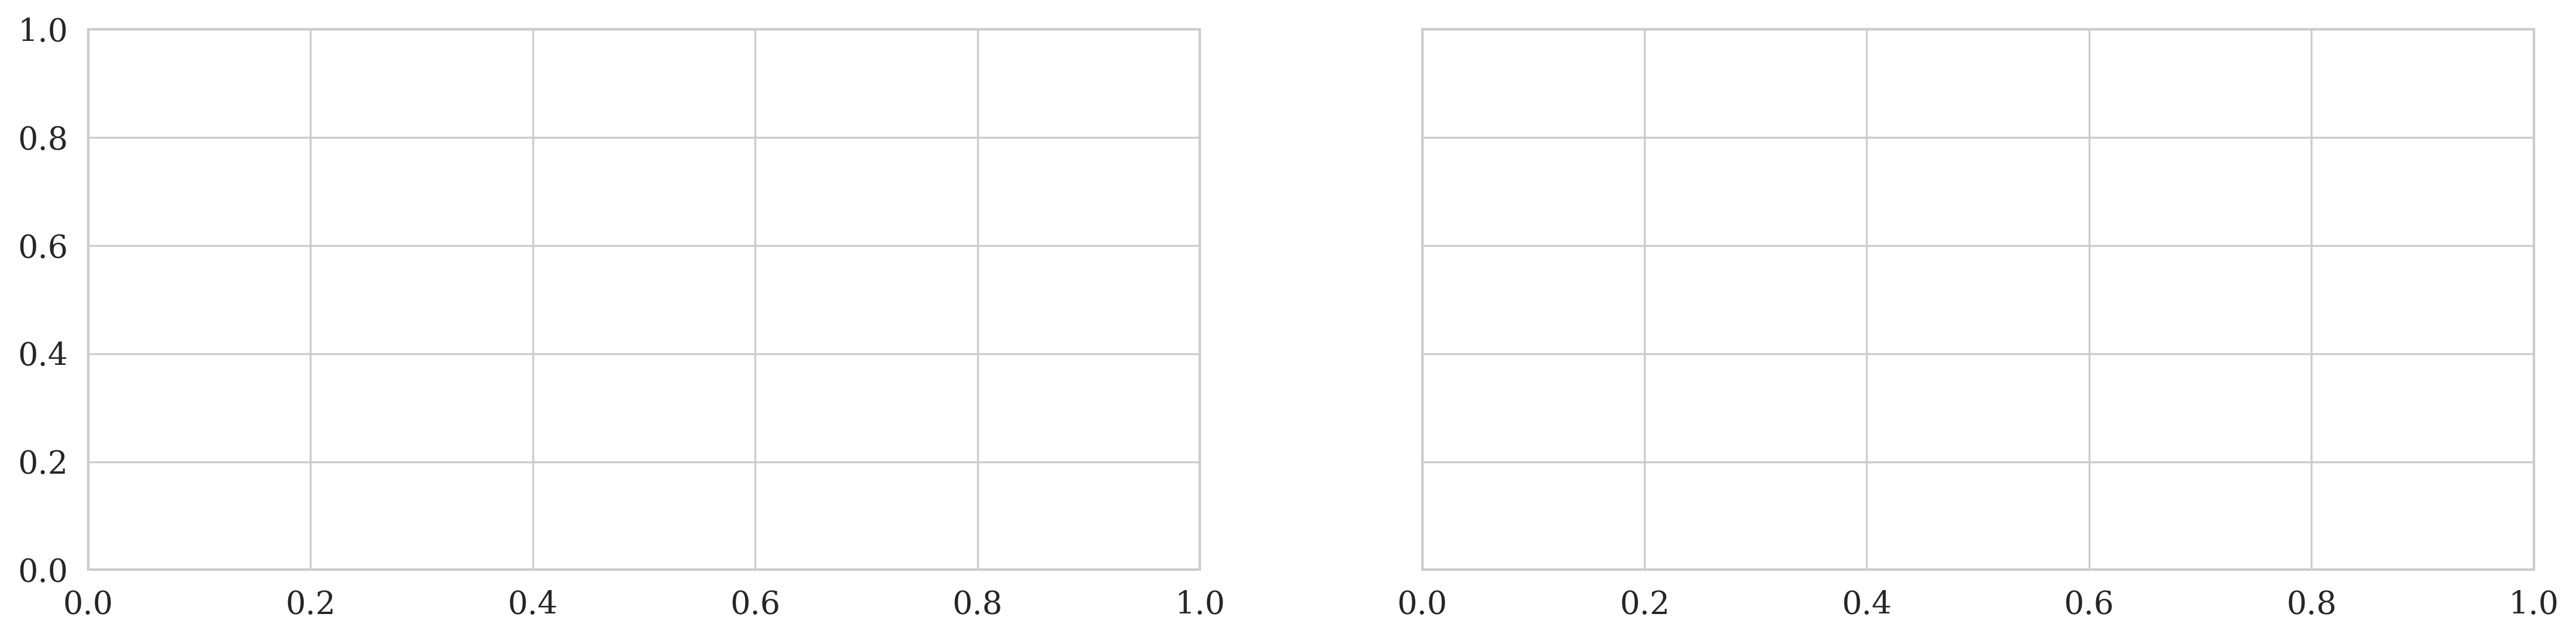

In [4]:

plot_mae_split_panels(
    models=['icind', 'pcind', 'dhcind', 'proposed', 'oracle'],
    model_names=['IPCW', "Standard\nMargin", 'Standard', 'Proposed', 'Oracle'],
    suffixes=params,
    suffixes_proper = ['Low Resource', 'High Resource'], 
    result_dir="$CWITE_DATA_ROOT/support50_propbin_data",
    preds_dir="$CWITE_DATA_ROOT/support50_propbin_test_preds",
    save_dir=".",
    method_order=['IPCW', "Standard\nMargin", 'Standard', 'Proposed', 'Oracle']
)

